# Fase 1 – Datakwaliteit & Validatie


**Doel van dit notebook:** Een definitieve analyseklare wijkdataset op jaarbasis waarbij ik de relevante data bij elkaar breng. 

-------------------------------

### Stap 1 – Dataset inlezen en eerste controle

In deze stap lees ik de gestructureerde dataset in en controleer ik de basisstructuur: aantal rijen, kolommen en datatypes.


In [24]:
import pandas as pd

# Pad naar de verwerkte dataset
# Notebook staat in notebooks/individual
# Daarom twee mappen omhoog en dan naar data/processed

data_path = "../../data/processed/df_v3_almere_wijken.csv"

# CSV-bestand inlezen
df = pd.read_csv(data_path)

# Aantal rijen en kolommen tonen
print("Shape:", df.shape)

# Overzicht van kolommen, datatypes en missende waarden
df.info()

# Eerste 5 rijen bekijken
df.head()

Shape: (237, 410)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Columns: 410 entries, ID to GeweldsEnSeksueleMisdrijven_90
dtypes: float64(388), int64(13), object(9)
memory usage: 759.3+ KB


,ID,Peildatum,Wijk,Gemeentenaam_1,SoortRegio_2,IndelingswijzigingGemeenteWijkBuurt_4,AantalInwoners_5,Mannen_6,Vrouwen_7,k_0Tot15Jaar_8,...,PersonenPerSoortUitkeringAO_81,PersonenPerSoortUitkeringWW_82,PersonenPerSoortUitkeringAOW_83,JongerenMetJeugdzorgInNatura_84,PercentageJongerenMetJeugdzorg_85,WmoClienten_86,WmoClientenRelatief_87,TotaalDiefstalUitWoningSchuurED_88,VernielingMisdrijfTegenOpenbareOrde_89,GeweldsEnSeksueleMisdrijven_90
0,385,1-1-2025,WK003401,Almere,Wijk,1.0,1810,880,930,220,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,388,1-1-2025,WK003402,Almere,Wijk,1.0,2890,1395,1500,485,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,394,1-1-2025,WK003403,Almere,Wijk,1.0,2500,1205,1300,445,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,399,1-1-2025,WK003404,Almere,Wijk,1.0,2220,1065,1155,370,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,403,1-1-2025,WK003405,Almere,Wijk,1.0,2365,1130,1235,425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Toelichting**

Met .info() controleer ik of de datatypes correct zijn.

Met .head() controleer ik of de eerste rijen logisch ogen.

-----------------------------------------------------------------------------------------------------------------------------

# Stap 2 – Missende waarden analyseren

Missende waarden kunnen analyses verstoren. Hier controleer ik per kolom of/en hoeveel waarden er ontbreken.

In [25]:
# Aantal missende waarden per kolom tellen
missing_counts = df.isnull().sum()

# Percentage missende waarden berekenen
missing_pct = (missing_counts / len(df)) * 100

# Overzicht maken in een nieuwe tabel
pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percentage": missing_pct
})

,missing_count,missing_percentage
ID,0,0.000000
Peildatum,0,0.000000
Wijk,0,0.000000
Gemeentenaam_1,0,0.000000
SoortRegio_2,0,0.000000
...,...,...
WmoClienten_86,232,97.890295
WmoClientenRelatief_87,232,97.890295
TotaalDiefstalUitWoningSchuurED_88,232,97.890295
VernielingMisdrijfTegenOpenbareOrde_89,232,97.890295


**Toelichting**:

Ik kijk hier of er ontbrekende waarden zijn per kolom en hoeveel procent dit is. Dit doe ik zodat ik zometeen kan kijken of ik de data wel of niet nodig heb en ik de data voor opheldering verder kan opschonen en verhelderen.

----------------------------------------------------------

# Stap 3 – Controle unieke Wijk + Jaar combinaties

Elke combinatie van wijk en jaar mag slechts één keer voorkomen. Dubbele combinaties wijzen op fouten of inconsitenties waar we iets mee zullen moeten. Hier ga ik na of en hoeveel dit voorkomt. 



In [26]:
# Controleren of er dubbele combinaties zijn van wijk en peildatum
df.duplicated(subset=["Wijk", "Peildatum"]).sum()

0

**Toelichting**:

Het getal is 0. Dit duidt aan op dat er geen dubbele data foutief is ingevoerd. 

----------------------------------

# Stap 4 – Controle op onlogische waarden

Hier controleer ik of numerieke kolommen geen negatieve of onrealistische waarden bevatten.

In [27]:
# Beschrijvende statistieken van alle numerieke kolommen tonen
df.describe()

# Lijst met belangrijke numerieke kolommen
numeric_cols = [
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9",
    "JongerenMetJeugdzorgInNatura_93"
]

# Controleren of er negatieve waarden voorkomen
for col in numeric_cols:
    if col in df.columns:
        print(col, "negatieve waarden:", (df[col] < 0).sum())

AantalInwoners_5 negatieve waarden: 0
k_0Tot15Jaar_8 negatieve waarden: 0
k_15Tot25Jaar_9 negatieve waarden: 0
JongerenMetJeugdzorgInNatura_93 negatieve waarden: 0


Ik controleer hier de numerieke tabellen op onlogische waarden door te kijken naar de minimum- en maximumwaarden.
zo weet ik of ik hier iets moet opschonen of dat de data betrouwbaar is geleverd.

----------------

# Stap 5 – Controle op wijkwijzigingen

Hier controleer ik of één wijkcode meerdere wijknamen heeft. Dit kan duiden op herindeling of naamswijziging.

In [28]:
# Groeperen op Wijk en tellen hoeveel unieke waarden er zijn
df.groupby("Wijk")["Wijk"].nunique().sort_values(ascending=False)

Wijk
WK003401      1
WK003402      1
WK003441      1
WK003442      1
WK003443      1
WK003444      1
WK003445      1
WK003446      1
WK003447      1
WK003448      1
WK003449      1
WK003450      1
WK003451      1
WK003452      1
WK003453      1
WK003456      1
WK003458      1
WK003459      1
WK003460      1
WK003461      1
WK003462      1
WK003463      1
WK003465      1
WK003466      1
WK003475      1
WK003476      1
WK003477      1
WK003437      1
WK003435      1
WK003432      1
WK003418      1
WK003403      1
WK003404      1
WK003405      1
WK003406      1
WK003407      1
WK003408      1
WK003409      1
WK003410      1
WK003411      1
WK003414      1
WK003417      1
WK003419      1
WK003431      1
WK003420      1
WK003421      1
WK003422      1
WK003423      1
WK003424      1
WK003425      1
WK003426      1
WK003427      1
WK003428      1
WK003429      1
WK003430      1
WK003485      1
Name: Wijk, dtype: int64

In [29]:
df["Wijk"].str.startswith("WK").sum()
# WK staat voor wijk, dus dit geeft het aantal unieke wijken in de dataset
print("Aantal unieke wijken:", df["Wijk"].str.startswith("WK").sum())

df["Wijk"].str.startswith("BU").sum()
# BU staat voor buurt, dus dit geeft het aantal unieke buurten in de dataset
print("Aantal unieke buurten:", df["Wijk"].str.startswith("BU").sum())


Aantal unieke wijken: 237
Aantal unieke buurten: 0


Ik controleer hier of elke wijkcode één unieke naam heeft en of er inconsitenties zijn tussen code en naam. 
wat me hier opvalt is dat er zowel BUcodes weggefilterd zijn dit is goed. Er zijn namelijk BU en WKcodes. Dit staat voor buurten en wijken. Als team willen we alleen wijken gebruiken dus hier doen we ook alleen iets mee.

------------------


# Stap 6 – Missende essentiële waarden verwijderen

Rijen met ontbrekende kerninformatie worden verwijderd om betrouwbaarheid van ons onderzoek te waarborgen.


In [30]:
# ===============================
# 1) Dataset inladen
# ===============================
input_path = "../../data/processed/df_v3_almere_wijken.csv"
df = pd.read_csv(input_path)

# Kolomnamen opschonen
df.columns = df.columns.astype(str).str.strip()
 
# ===============================
# 2) Relevante kolommen selecteren
# ===============================
selected_cols = [
    "Peildatum",
    "Wijk",   # nieuwe hernoemde kolom
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9",
]
 
# Controle of alle kolommen bestaan
missing = [col for col in selected_cols if col not in df.columns]
 
if missing:
    print("⚠️ Deze kolommen ontbreken:")
    for col in missing:
        print("-", col)
 
# Alleen bestaande kolommen selecteren
available_cols = [col for col in selected_cols if col in df.columns]
df_selected = df[available_cols].copy()
 
# ===============================
# 3) Kolommen hernoemen (netter)
# ===============================
rename_map = {
    "AantalInwoners_5": "AantalInwoners",
    "k_0Tot15Jaar_8": "Aandeel_0_15",
    "k_15Tot25Jaar_9": "Aandeel_15_25",
    "JongerenMetJeugdzorgInNatura_93": "JeugdzorgNatura",
}
 
df_selected = df_selected.rename(columns=rename_map)
 
print("Kolommen in output:", df_selected.columns.tolist())
print("Aantal rijen:", len(df_selected))

Kolommen in output: ['Peildatum', 'Wijk', 'AantalInwoners', 'Aandeel_0_15', 'Aandeel_15_25']
Aantal rijen: 237


**Toelichting**

Hiermee zorg ik dat alleen complete en betrouwbare observaties overblijven.

---------------------------------

# Stap 7 – Sorteren en opslaan

Tot slot sorteer ik de dataset op wijk en jaar en sla ik deze op als definitieve versie.

In [31]:
# Peildatum omzetten naar datumtype (dag-maand-jaar volgorde)
df["Peildatum"] = pd.to_datetime(df["Peildatum"], dayfirst=True)

# Sorteren op wijk en datum (chronologisch per wijk)
df = df.sort_values(["Wijk", "Peildatum"]).reset_index(drop=True)

# Definitieve schone dataset opslaan
df.to_csv("../../data/processed/df_v5_clean_final.csv", index=False)

**Toelichting**

Hier heb ik de dataset opgeschoond en ervoor gezorgd dat er
    - Geen dubbele wijk-jaar 
    - Gecontroleerde numerieke waarden
    - Geanalyseerde missende waarden
    - Gestructureerde tijdsvolgorde
meer zijn. De dataset is nu geschikt voor verdere analyse.

----------------

# controle

Ik doe nog een eindcheck om te controleren of het is gelukt. 

In [32]:

# EINDSCHECK DATASET

expected_cols = [
    "Peildatum",
    "Wijk",
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9",
]

print("---- Kolomcontrole ----")
print("Huidige kolommen:", df.columns.tolist())

missing_cols = set(expected_cols) - set(df.columns)
extra_cols = set(df.columns) - set(expected_cols)

print("Ontbrekende kolommen:", missing_cols)
print("Extra kolommen:", extra_cols)

print("\n---- Missende waarden ----")
print(df[expected_cols].isna().sum())

print("\n---- Dubbele wijk-jaar combinaties ----")
print("Aantal duplicaten:", df.duplicated(subset=["Wijk", "Peildatum"]).sum())

print("\n---- Negatieve waarden ----")
numeric_cols = [
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9",
]

for col in numeric_cols:
    print(col, "negatief:", (df[col] < 0).sum())

print("\n---- Controle afgerond ----")

---- Kolomcontrole ----
Huidige kolommen: ['ID', 'Peildatum', 'Wijk', 'Gemeentenaam_1', 'SoortRegio_2', 'IndelingswijzigingGemeenteWijkBuurt_4', 'AantalInwoners_5', 'Mannen_6', 'Vrouwen_7', 'k_0Tot15Jaar_8', 'k_15Tot25Jaar_9', 'k_25Tot45Jaar_10', 'k_45Tot65Jaar_11', 'k_65JaarOfOuder_12', 'Ongehuwd_13', 'Gehuwd_14', 'Gescheiden_15', 'Verweduwd_16', 'Nederland_17', 'EuropaExclusiefNederland_18', 'BuitenEuropa_19', 'Nederland_20', 'EuropaExclusiefNederland_21', 'BuitenEuropa_22', 'EuropaExclusiefNederland_23', 'BuitenEuropa_24', 'GeboorteTotaal_25', 'GeboorteRelatief_26', 'SterfteTotaal_27', 'SterfteRelatief_28', 'HuishoudensTotaal_29', 'Eenpersoonshuishoudens_30', 'HuishoudensZonderKinderen_31', 'HuishoudensMetKinderen_32', 'GemiddeldeHuishoudensgrootte_33', 'Bevolkingsdichtheid_34', 'Woningvoorraad_35', 'NieuwbouwWoningen_36', 'NietWoningvoorraad_37', 'NieuwbouwNietWoningen_38', 'GemiddeldeWOZWaardeVanWoningen_39', 'PercentageEengezinswoning_40', 'PercentageTussenwoningEengezins_41', 'P

Ik zie dat de kolommen nog niet helemaal goed zijn gefilterd. 

In [33]:
# Alleen relevante kolommen behouden
keep_cols = [
    "Peildatum",
    "Wijk",
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9",
]

df = df[keep_cols].copy()

print("Nieuwe kolommen:", df.columns.tolist())
print("Nieuwe shape:", df.shape)
df.head()

Nieuwe kolommen: ['Peildatum', 'Wijk', 'AantalInwoners_5', 'k_0Tot15Jaar_8', 'k_15Tot25Jaar_9']
Nieuwe shape: (237, 5)


,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9
0,2018-01-01,WK003401,22790,3975,2420
1,2019-01-01,WK003401,22875,3945,2415
2,2020-01-01,WK003401,23275,4005,2485
3,2021-01-01,WK003401,23530,4180,2465
4,2022-01-01,WK003401,1635,175,150


In [34]:
df.to_csv("../../data/processed/df_v5_clean_final.csv", index=False)

Nu zou het moeten kloppen, toch doe ik een eindcheck.

In [35]:

# EINDSCHECK DATASET

expected_cols = [
    "Peildatum",
    "Wijk",
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9",
]

print("---- Kolomcontrole ----")
print("Huidige kolommen:", df.columns.tolist())

missing_cols = set(expected_cols) - set(df.columns)
extra_cols = set(df.columns) - set(expected_cols)

print("Ontbrekende kolommen:", missing_cols)
print("Extra kolommen:", extra_cols)

print("\n---- Missende waarden ----")
print(df[expected_cols].isna().sum())

print("\n---- Dubbele wijk-jaar combinaties ----")
print("Aantal duplicaten:", df.duplicated(subset=["Wijk", "Peildatum"]).sum())

print("\n---- Negatieve waarden ----")
numeric_cols = [
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9",
]

for col in numeric_cols:
    print(col, "negatief:", (df[col] < 0).sum())

print("\n---- Controle afgerond ----")

---- Kolomcontrole ----
Huidige kolommen: ['Peildatum', 'Wijk', 'AantalInwoners_5', 'k_0Tot15Jaar_8', 'k_15Tot25Jaar_9']
Ontbrekende kolommen: set()
Extra kolommen: set()

---- Missende waarden ----
Peildatum           0
Wijk                0
AantalInwoners_5    0
k_0Tot15Jaar_8      0
k_15Tot25Jaar_9     0
dtype: int64

---- Dubbele wijk-jaar combinaties ----
Aantal duplicaten: 0

---- Negatieve waarden ----
AantalInwoners_5 negatief: 0
k_0Tot15Jaar_8 negatief: 0
k_15Tot25Jaar_9 negatief: 0

---- Controle afgerond ----


Ik zie inderdaad dat er geen onbrekende kolommen of extra kolommen meer zijn. 

# Fase 2 – Data understanding

-------------------------------



In deze fase onderzoeken we hoe de jeugd (0–25 jaar) verdeeld is over de wijken in Almere.

We kijken naar:
- het percentage jeugd per wijk
- mogelijke fouten in de data
- verschillen tussen wijken

In [36]:
import pandas as pd

df = pd.read_csv(
    "C:/A-data_science/almere-jeugd-voorspelling/data/processed/CBS_Kerncijfers_cleaned.csv",
    sep=";"
)

print("Shape:", df.shape)
df.head()

Shape: (1141, 411)


,ID,Peildatum,WijkenEnBuurten,Gemeentenaam_1,SoortRegio_2,Codering_3,IndelingswijzigingGemeenteWijkBuurt_4,AantalInwoners_5,Mannen_6,Vrouwen_7,...,PersonenPerSoortUitkeringAO_81,PersonenPerSoortUitkeringWW_82,PersonenPerSoortUitkeringAOW_83,JongerenMetJeugdzorgInNatura_84,PercentageJongerenMetJeugdzorg_85,WmoClienten_86,WmoClientenRelatief_87,TotaalDiefstalUitWoningSchuurED_88,VernielingMisdrijfTegenOpenbareOrde_89,GeweldsEnSeksueleMisdrijven_90
0,384,1-1-2025,GM0034,Almere,Gemeente,GM0034,1.0,229574,113738,115836,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,385,1-1-2025,WK003401,Almere,Wijk,WK003401,1.0,1810,880,930,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,386,1-1-2025,BU00340101,Almere,Buurt,BU00340101,1.0,795,415,385,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,387,1-1-2025,BU00340102,Almere,Buurt,BU00340102,1.0,1010,465,545,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,388,1-1-2025,WK003402,Almere,Wijk,WK003402,1.0,2890,1395,1500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Dataset controle**

Hier controleren we of de dataset correct is ingelezen.

Met `shape` zien we hoeveel rijen en kolommen de dataset bevat.

**Percentage jeugd berekenen**

We berekenen het percentage inwoners dat:

- 0–15 jaar is
- 15–25 jaar is
- totaal 0–25 jaar is

Dit doen we door het aantal jongeren te delen door het totaal aantal inwoners.

In [37]:
df["Perc_0_15"] = (df["k_0Tot15Jaar_8"] / df["AantalInwoners_5"]) * 100
df["Perc_15_25"] = (df["k_15Tot25Jaar_9"] / df["AantalInwoners_5"]) * 100
df["Perc_TotaleJeugd"] = df["Perc_0_15"] + df["Perc_15_25"]

df[["Perc_0_15", "Perc_15_25", "Perc_TotaleJeugd"]].head()

,Perc_0_15,Perc_15_25,Perc_TotaleJeugd
0,18.032965,12.202601,30.235567
1,12.154696,8.839779,20.994475
2,20.754717,13.207547,33.962264
3,5.940594,4.950495,10.891089
4,16.782007,10.899654,27.681661


**Toelichting**

We hebben nu drie nieuwe kolommen gemaakt die het percentage jeugd laten zien.

Dit maakt het makkelijker om wijken met elkaar te vergelijken.

**Beschrijvende statistieken**

We bekijken statistieken van de percentages om te zien hoe de waarden verdeeld zijn.

In [38]:
df[["Perc_0_15", "Perc_15_25", "Perc_TotaleJeugd"]].describe()

,Perc_0_15,Perc_15_25,Perc_TotaleJeugd
count,1141.000000,1141.000000,1141.000000
mean,18.009914,12.757745,30.767658
std,5.538173,5.744983,7.851645
min,2.083333,3.626943,8.247423
25%,15.267176,10.154525,26.681128
50%,17.252396,12.094763,30.243446
75%,20.000000,14.388489,33.720930
max,57.142857,83.333333,116.666667


**Toelichting**

Met `describe()` zien we:

- gemiddelde
- minimum
- maximum
- spreiding van de percentages

We controleren of het percentage jeugd boven de 100% komt.
Dit zou namelijk niet mogelijk moeten zijn.

In [39]:
df[df["Perc_TotaleJeugd"] > 100][
    [
        "WijkenEnBuurten",
        "AantalInwoners_5",
        "k_0Tot15Jaar_8",
        "k_15Tot25Jaar_9",
        "Perc_TotaleJeugd"
    ]
]

,WijkenEnBuurten,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Perc_TotaleJeugd
824,WK003437,30,10,25,116.666667
825,BU00343701,30,10,25,116.666667


**Toelichting**

het percentage komt boven de 100%, dit betekent dat er waarschijnlijk een fout in deze data zit. Je kan namelijk niet meer dan 100 procent hebben.

**Extra controle**

Hier controleren we of het aantal jongeren groter is dan het totaal aantal inwoners.
Dit is statistisch onmogelijk.

In [40]:
df[(df["k_0Tot15Jaar_8"] + df["k_15Tot25Jaar_9"]) > df["AantalInwoners_5"]]

,ID,Peildatum,WijkenEnBuurten,Gemeentenaam_1,SoortRegio_2,Codering_3,IndelingswijzigingGemeenteWijkBuurt_4,AantalInwoners_5,Mannen_6,Vrouwen_7,...,JongerenMetJeugdzorgInNatura_84,PercentageJongerenMetJeugdzorg_85,WmoClienten_86,WmoClientenRelatief_87,TotaalDiefstalUitWoningSchuurED_88,VernielingMisdrijfTegenOpenbareOrde_89,GeweldsEnSeksueleMisdrijven_90,Perc_0_15,Perc_15_25,Perc_TotaleJeugd
824,556,1-1-2022,WK003437,Almere,Wijk,WK003437,3.0,30,20,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.333333,83.333333,116.666667
825,557,1-1-2022,BU00343701,Almere,Buurt,BU00343701,3.0,30,20,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.333333,83.333333,116.666667


**Toelichting**

Het blijkt dat deze twee rijen foutief zijn en dus niet betrouwbaar zijn om mee te werken. Om deze reden zullen we deze verwijderen. 

In [41]:
df = df[df["Perc_TotaleJeugd"] <= 100]

**Nieuwe statistieken na opschonen**

We controleren opnieuw de statistieken om te zien of de waarden nu logisch zijn.

In [42]:
df[["Perc_TotaleJeugd"]].describe()

,Perc_TotaleJeugd
count,1139.000000
mean,30.616826
std,6.983278
min,8.247423
25%,26.673897
50%,30.235567
75%,33.698762
max,100.000000


**Wat betekent dit?**

Gemiddeld is ongeveer **30% van de inwoners jeugd (0–25 jaar)**.

De meeste wijken zitten tussen **26% en 34% jeugd**.

Sommige wijken hebben weinig jeugd, terwijl andere wijken juist relatief veel jongeren hebben.

**Gemiddeld percentage jeugd per gebied**

In [43]:
gemiddeld = df.groupby("WijkenEnBuurten")["Perc_TotaleJeugd"].mean()

print(gemiddeld.sort_values(ascending=False))

WijkenEnBuurten
BU00340299    81.547619
WK003460      55.087411
BU00346001    52.538928
BU00348501    50.000000
BU00340404    49.023173
                ...    
BU00340171    17.663818
BU00341704    16.571066
BU00347501    16.513122
BU00343201    12.372449
WK003432      12.351190
Name: Perc_TotaleJeugd, Length: 273, dtype: float64


**Visualisatie van gebieden met veel jeugd**

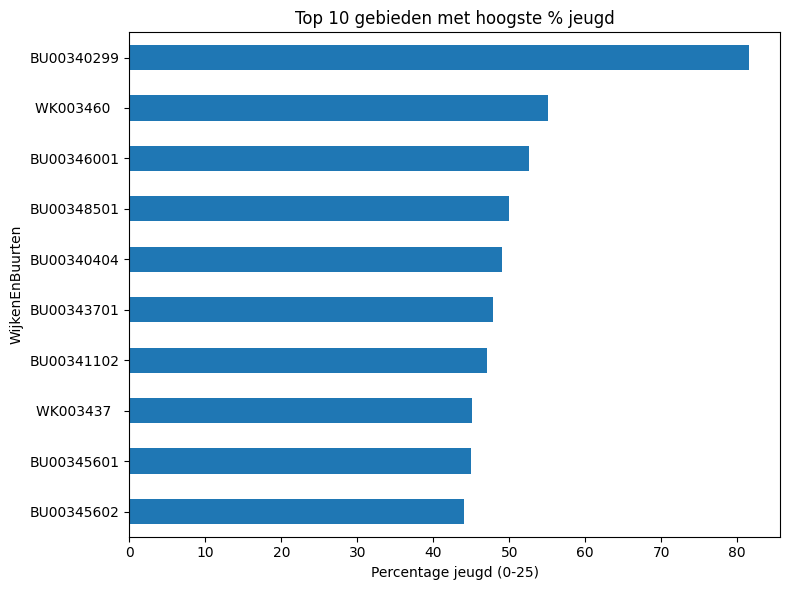

In [44]:
import matplotlib.pyplot as plt

top10 = gemiddeld.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
top10.sort_values().plot(kind="barh")

plt.title("Top 10 gebieden met hoogste % jeugd")
plt.xlabel("Percentage jeugd (0-25)")
plt.tight_layout()
plt.show()

**Alleen wijken analyseren (WK)**

De dataset bevat ook buurten en wijken.
Daarom filteren we alleen de codes die beginnen met **WK**.

In [45]:
df_wijk = df[df["Codering_3"].str.startswith("WK")]

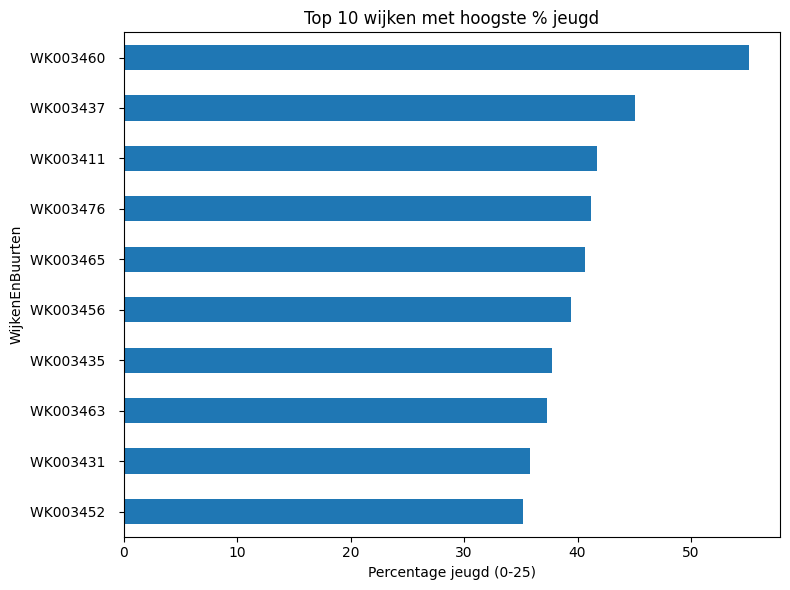

In [46]:
import matplotlib.pyplot as plt

# visualiseren van de top 10 wijken met hoogste % jeugd
gemiddeld_wijk = df_wijk.groupby("WijkenEnBuurten")["Perc_TotaleJeugd"].mean()
top10_wijk = gemiddeld_wijk.sort_values(ascending=False).head(10)   


plt.figure(figsize=(8,6))
top10_wijk.sort_values().plot(kind="barh")
plt.title("Top 10 wijken met hoogste % jeugd")
plt.xlabel("Percentage jeugd (0-25)")
plt.tight_layout()
plt.show()
    

In [47]:
df_wijk[["Perc_TotaleJeugd"]].describe()

,Perc_TotaleJeugd
count,236.000000
mean,30.720324
std,6.730680
min,10.416667
25%,27.810195
50%,29.788587
75%,32.772947
max,85.714286


**Conclusie**

Uit de analyse blijkt dat gemiddeld ongeveer **30% van de inwoners in Almere jeugd (0–25 jaar)** is.  
De meeste wijken liggen tussen **26% en 34% jeugd**.

Er zijn wel verschillen tussen wijken: sommige wijken hebben duidelijk meer jongeren dan andere.  
Dit inzicht helpt om beter te begrijpen waar in Almere relatief veel jeugd woont.
Zo kan de gemeente ook uiteindelijk eventueel inschatten welke buurten het meest aandacht nodig hebben. 

------------


# Fase 3
**Dataset model-klaar maken**

**Input:**  
`../../data/processed/df_v8_ready_for_analysis.csv`

**Output:**  
`../../data/processed/df_v12_model_ready.csv`

### Doel
De dataset voorbereiden voor modellering.

In deze stap maak ik een lag feature.  
Een lag feature gebruikt een waarde van het vorige jaar als voorspeller voor het huidige jaar.

Dit kan helpen om trends in de data beter te modelleren.

In [48]:
import pandas as pd

# dataset laden
input_path = "../../data/processed/df_v8_ready_for_analysis.csv"
df = pd.read_csv(input_path)

print(df.shape)
df.head()

(237, 8)


,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988
4,2022-01-01,WK003401,1635,175,150,2022,10.703364,9.174312


**Toelichting**

We laden de dataset in die klaar is voor analyse.  
Hier controleren we of de dataset correct is ingelezen en hoeveel rijen en kolommen aanwezig zijn.

**Lag feature maken**

We maken een nieuwe variabele die de waarde van het **vorige jaar** bevat.

Bijvoorbeeld:

| Wijk | Jaar | Jeugdzorg | Jeugdzorg_lag1 |
|-----|-----|-----|-----|
| WK1 | 2022 | 120 | NaN |
| WK1 | 2023 | 130 | 120 |
| WK1 | 2024 | 140 | 130 |

De lag-variabele kan later gebruikt worden als **predictor in het model**.

In [49]:
# dataset sorteren op wijk en jaar
df = df.sort_values(["Wijk", "Jaar"])

# Jeugdzorg variabele: totaal aantal jongeren (0-15 + 15-25)
df["Jeugdzorg"] = df["k_0Tot15Jaar_8"] + df["k_15Tot25Jaar_9"]

# lag variabele maken (vorig jaar waarde)
df["Jeugdzorg_lag1"] = df.groupby("Wijk")["Jeugdzorg"].shift(1)

df.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25,Jeugdzorg,Jeugdzorg_lag1
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692,6395,NaN
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377,6360,6395.0
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692,6490,6360.0
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988,6645,6490.0
4,2022-01-01,WK003401,1635,175,150,2022,10.703364,9.174312,325,6645.0


### Toelichting

Met `groupby("Wijk")` zorgen we dat de lag alleen binnen dezelfde wijk wordt berekend.

De functie `shift(1)` verschuift de waarden één jaar naar beneden, waardoor de waarde van het vorige jaar beschikbaar wordt als nieuwe variabele.

**Missende waarden controleren**

Voor het eerste jaar per wijk bestaat geen vorig jaar.  
Daarom krijgt de lag-variabele daar een **NaN** waarde.

In [50]:
# rijen zonder lag verwijderen
df = df.dropna(subset=["Jeugdzorg_lag1"])

print(df.shape)

(181, 10)


**Toelichting**

Rijen zonder lag-waarde worden verwijderd omdat deze niet bruikbaar zijn voor het model.

In [51]:
# dataset opslaan
output_path = "../../data/processed/df_v12_model_ready.csv"
df.to_csv(output_path, index=False)

print("Dataset opgeslagen:", output_path)

Dataset opgeslagen: ../../data/processed/df_v12_model_ready.csv


**Resultaat**

De dataset bevat nu een extra lag feature die de waarde van het vorige jaar bevat.

Deze dataset is nu klaar voor modellering en kan gebruikt worden in de volgende fase van het project.

**Waarom is een lag feature belangrijk?**

Een lag feature gebruikt informatie uit het vorige jaar om het huidige jaar te voorspellen.  
Bij veel data veranderen waarden namelijk geleidelijk over tijd.
Bijvoorbeeld: als een wijk vorig jaar veel jongeren had die jeugdzorg gebruikten, is de kans groot dat dit dit jaar ook zo is. Door deze vorige waarde toe te voegen aan het model, kan het model patronen en trends beter herkennen.
Dit kan de voorspelkracht van het model verbeteren, omdat het model niet alleen naar de huidige situatie kijkt, maar ook naar hoe de situatie zich in de tijd ontwikkelt.


-------------------


# Fase 4 – Modeling

 Groei Model

**Input:**  
`../../data/processed/df_v12_model_ready.csv`

**Target variabele:**  
`k_0Tot15Jaar_8`

**Doel**

In dit model onderzoeken we of de groei van de jeugdpopulatie in eerdere jaren gebruikt kan worden om de huidige jeugdpopulatie te voorspellen.

We gebruiken hiervoor een enkelvoudige lineaire regressie.

In [52]:
import pandas as pd

# dataset laden
input_path = "../../data/processed/df_v12_model_ready.csv"

print(df.shape)
df.head()

(181, 10)


,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25,Jeugdzorg,Jeugdzorg_lag1
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377,6360,6395.0
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692,6490,6360.0
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988,6645,6490.0
4,2022-01-01,WK003401,1635,175,150,2022,10.703364,9.174312,325,6645.0
5,2023-01-01,WK003401,1740,190,160,2023,10.919540,9.195402,350,325.0


**Toelichting**

Hier laden we de dataset die al voorbereid is voor modellering.  
We controleren of de dataset correct is ingelezen.

**Groei per jaar berekenen**

Om de groeitrend te analyseren berekenen we de procentuele groei van het aantal jongeren (0–15 jaar) ten opzichte van het vorige jaar.

In [53]:
# sorteren op wijk en jaar
df = df.sort_values(["Wijk", "Jaar"])

# groeipercentage berekenen
df["Groei_Jeugd_pct"] = df.groupby("Wijk")["k_0Tot15Jaar_8"].pct_change() * 100

df[["Wijk","Jaar","k_0Tot15Jaar_8","Groei_Jeugd_pct"]].head()

,Wijk,Jaar,k_0Tot15Jaar_8,Groei_Jeugd_pct
1,WK003401,2019,3945,NaN
2,WK003401,2020,4005,1.520913
3,WK003401,2021,4180,4.369538
4,WK003401,2022,175,-95.813397
5,WK003401,2023,190,8.571429


**Toelichting**

Met `pct_change()` berekenen we hoeveel het aantal jongeren is veranderd ten opzichte van het vorige jaar.

Dit geeft ons een groeipercentage per jaar per wijk.

**Dataset opschonen**

De eerste rij per wijk heeft geen vorige waarde, dus daar ontstaat een NaN.  
Deze rijen verwijderen we voordat we het model trainen.

In [54]:
df_model = df.dropna(subset=["Groei_Jeugd_pct"])

print(df_model.shape)

(126, 11)


**Lineaire regressie uitvoeren**

We onderzoeken of de groei van de jeugdpopulatie kan helpen om het aantal jongeren te voorspellen.

Predictor (X):
- Groei_Jeugd_pct

Target (y):
- k_0Tot15Jaar_8

In [55]:
from sklearn.linear_model import LinearRegression

X = df_model[["Groei_Jeugd_pct"]]
y = df_model["k_0Tot15Jaar_8"]

model = LinearRegression()
model.fit(X,y)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 1313.0165159426153
Coefficient: -0.520290228755033


**Uitleg van het model**

Het intercept (1313) betekent dat als de groei 0% is, het model verwacht dat er ongeveer 1313 jongeren (0–15 jaar) in een wijk wonen.

De coëfficiënt (-0,52) betekent dat als de groei met 1% stijgt, het aantal jongeren volgens het model ongeveer 0,5 lager wordt. Dit verschil is heel klein, dus de relatie is zwak.

hoe kan de relatie nou zwak zijn?

De groei zegt niet altijd veel over het totale aantal jongeren.

Bijvoorbeeld:
- Een grote wijk kan weinig groeien maar toch veel jongeren hebben.
- Een kleine wijk kan snel groeien maar nog steeds weinig jongeren hebben.

Ook spelen andere dingen een rol, zoals nieuwbouw, verhuizingen en gezinnen.  
Daarom kan alleen de groeitrend meestal niet goed voorspellen hoeveel jongeren er zijn.

**Scatterplot van de relatie**

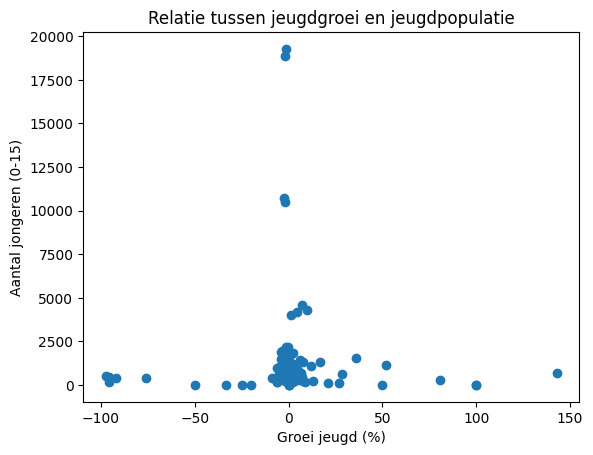

In [56]:

import matplotlib.pyplot as plt

plt.scatter(df_model["Groei_Jeugd_pct"], df_model["k_0Tot15Jaar_8"])

plt.xlabel("Groei jeugd (%)")
plt.ylabel("Aantal jongeren (0-15)")
plt.title("Relatie tussen jeugdgroei en jeugdpopulatie")

plt.show()

**Toelichting op de scatterplot**

In deze grafiek zien we de relatie tussen groei van de jeugd (%) op de x-as en het aantal jongeren (0–15 jaar) op de y-as.

De punten liggen vrij verspreid en vormen geen duidelijke lijn. Dit betekent dat er geen sterke relatie is tussen de groei van jongeren en het totale aantal jongeren in een wijk.

We zien ook dat:
- De meeste wijken rond 0% groei liggen.
- Sommige wijken extreme groei of krimp hebben, maar toch weinig jongeren.
- Een paar wijken heel veel jongeren hebben, maar hun groei nog steeds rond 0% ligt.

Dit laat zien dat de groei van eerdere jaren niet goed voorspelt hoeveel jongeren er in een wijk wonen. Andere factoren, zoals de grootte van de wijk of het type woningen, spelen waarschijnlijk een grotere rol.

**R² berekenen**

In [57]:
r2 = model.score(X,y)

print("R²:", r2)

R²: 3.091327224746809e-05


**Conclusie van het model**

De R² waarde laat zien hoeveel van de variatie in het aantal jongeren (0–15 jaar) verklaard wordt door de groeitrend.

De waarde wordt berekend met r2 = model.score(X,y)

Een lage R² betekent dat de groeitrend maar een klein deel van het aantal jongeren kan verklaren.

Samen met de scatterplot zien we dat de punten vrij verspreid liggen en geen duidelijke lijn vormen. Dit betekent dat de groei van jongeren in eerdere jaren geen sterke voorspeller is voor het huidige aantal jongeren in een wijk.

Waarschijnlijk spelen andere factoren een grotere rol, zoals de grootte van de wijk, nieuwbouw, verhuizingen of de samenstelling van gezinnen.


------------------
